In [1]:
import pandas as pd 

data = pd.read_csv('sub_votes.csv',encoding='utf-8')

data.rename(columns={'0': 'address', '1': 'score'}, inplace=True)


# sub_votes  sub_bt_scores



# data_address = data['Name']
# target = data['MOS']


In [2]:
data['address'] = data['address'].apply(lambda x: x.strip('[]'))

data['address'] = data['address'].apply(lambda x: x.strip("''"))

data['score'] = data['score'].apply(lambda x: x.strip('[]'))

data['score'] = data['score'].apply(lambda x: x.strip('[]'))



In [3]:
data_address = data['address']
target = data['score'].apply(lambda x: float(x))

print(data_address,target)

0                     group_1/1/1_BL-TM.png
1                    group_1/1/1_GL-net.png
2           group_1/1/1_histogram prior.png
3      group_1/1/1_RayleighDistribution.png
4             group_1/1/1_retinex-based.png
                       ...                 
995                  group_5/20/20_RGHS.png
996        group_5/20/20_two-step-based.png
997                  group_5/20/20_UDCP.png
998                 group_5/20/20_UWCNN.png
999             group_5/20/20_Water-net.png
Name: address, Length: 1000, dtype: object 0      52.0
1      82.0
2      18.0
3       8.0
4      20.0
       ... 
995    67.0
996    50.0
997    16.0
998     0.0
999    61.0
Name: score, Length: 1000, dtype: float64


In [1]:
# # finding best block size for local numinance : 
# import cv2
# import numpy as np

# def compute_local_contrast(image, block_size):
#     local_mean = cv2.blur(image, (block_size, block_size))
#     local_contrast = np.abs(image - local_mean)
#     return local_contrast

# def evaluate_contrast(local_contrast):
#     # Example metric: Mean of local contrast
#     return np.mean(local_contrast)

# # Load an image
# image = cv2.imread('example.jpg', cv2.IMREAD_GRAYSCALE)

# # Define block sizes to test
# block_sizes = [16, 32, 64, 128]

# best_block_size = None
# best_score = -float('inf')

# for block_size in block_sizes:
#     local_contrast = compute_local_contrast(image, block_size)
#     score = evaluate_contrast(local_contrast)
    
#     if score > best_score:
#         best_score = score
#         best_block_size = block_size

# print(f'Best block size: {best_block_size}')


In [2]:
# sigma_values = [0.5, 1, 1.5, 2, 2.5, 3]
# def test_sigma_values(image, sigma_values):
#     """
#     Test different sigma values to find the best one for sharpness estimation.

#     Parameters:
#     image (ndarray): Input image (grayscale).
#     sigma_values (list): List of sigma values to test.

#     Returns:
#     dict: Dictionary of sigma values and their corresponding sharpness values.
#     """
#     results = {}
#     for sigma in sigma_values:
#         sharpness = calculate_log_sharpness(image, sigma=sigma)
#         results[sigma] = sharpness
#         print(f"Sigma: {sigma}, Sharpness: {sharpness}")
#     return results

In [3]:
# import numpy as np
# import cv2
# from scipy.fft import fft2, ifft2, fftshift, ifftshift

# def high_pass_filter(size, cutoff):
#     rows, cols = size
#     crow, ccol = rows // 2, cols // 2
#     filter = np.ones((rows, cols), np.float32)
#     r, c = np.ogrid[:rows, :cols]
#     distance = np.sqrt((r - crow) ** 2 + (c - ccol) ** 2)
#     filter[distance <= cutoff] = 0
#     return filter

# def frequency_domain_sharpness(image, cutoff=30):
#     gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
#     gray_image = np.float32(gray_image)
#     f_transform = fft2(gray_image)
#     f_transform_shifted = fftshift(f_transform)
#     hp_filter = high_pass_filter(gray_image.shape, cutoff)
#     filtered_transform = f_transform_shifted * hp_filter
#     filtered_image = np.abs(ifft2(ifftshift(filtered_transform)))
#     sharpness = np.var(filtered_image)
#     return sharpness

# # Example usage for tuning
# if __name__ == "__main__":
#     image = cv2.imread('path_to_image.jpg')
    
#     best_cutoff = 0
#     best_sharpness = -np.inf
#     for cutoff in range(10, 100, 5):  # Adjust range and step as needed
#         sharpness_value = frequency_domain_sharpness(image, cutoff)
#         if sharpness_value > best_sharpness:
#             best_sharpness = sharpness_value
#             best_cutoff = cutoff
    
#     print("Optimal Cutoff Frequency:", best_cutoff)
#     print("Best Sharpness Value:", best_sharpness)


In [4]:
# def find_best_sigma(image, sigma_values):
#     """Find the best sigma value for Canny edge detection."""
#     best_sigma = None
#     best_sharpness = -np.inf
    
#     for sigma in sigma_values:
#         sharpness = canny_sharpness(image, sigma)
#         print(f"Sigma: {sigma}, Sharpness: {sharpness}")
        
#         if sharpness > best_sharpness:
#             best_sharpness = sharpness
#             best_sigma = sigma
    
#     return best_sigma, best_sharpness
# def find_best_thresholds(image, sigma=1.0, thresholds=[(50, 150), (100, 200), (150, 250)]):
#     """Find the best thresholds for Canny edge detection."""
#     best_thresholds = None
#     best_sharpness = -np.inf
    
#     for threshold1, threshold2 in thresholds:
#         sharpness = canny_sharpness(image, sigma, threshold1, threshold2)
#         print(f"Threshold1: {threshold1}, Threshold2: {threshold2}, Sharpness: {sharpness}")
        
#         if sharpness > best_sharpness:
#             best_sharpness = sharpness
#             best_thresholds = (threshold1, threshold2)
    
#     return best_thresholds, best_sharpness


#### Methods :
* 

In [4]:
import numpy as np
import cv2
from skimage import filters, metrics
from skimage import io, img_as_float, color
from skimage.filters import gaussian, sobel,laplace
from skimage.restoration import denoise_tv_chambolle
from skimage import io, color, morphology, exposure
from scipy.fft import fft2, ifft2, fftshift, ifftshift
from skimage import img_as_ubyte
from skimage.feature import local_binary_pattern
import matplotlib.pyplot as plt
from scipy.special import gamma
from scipy.optimize import minimize
import csv
import pywt
#brightness

def perceived_luminance(image):
    """
    Calculate perceived luminance for an image.

    Parameters:
        image (numpy.ndarray): Input image as a 3D numpy array (H, W, 3).

    Returns:
        float: Mean luminance of the image.
    """
    # image = image.astype(np.float32) / 255.0
    R, G, B = image[:, :, 0], image[:, :, 1], image[:, :, 2]
    luminance = np.sqrt(0.299 * R**2 + 0.587 * G**2 + 0.114 * B**2)
    return np.mean(luminance)

def block_perceived_luminance(image, block_size):
    image = image.astype(np.float32) / 255.0
    """
    Calculate perceived luminance for each block of an image.

    Parameters:
        image (numpy.ndarray): Input image as a 3D numpy array (H, W, 3).
        block_size (tuple): Block size as (block_height, block_width).

    Returns:
        numpy.ndarray: A 2D array containing the mean luminance for each block.
    """
    # Extract block size dimensions
    block_height, block_width = block_size

    # Calculate the number of blocks along height and width
    H, W, _ = image.shape
    blocks_vertical = H // block_height
    blocks_horizontal = W // block_width

    # Initialize the output array to store block luminance values
    block_luminance = np.zeros((blocks_vertical, blocks_horizontal))

    # Loop through each block and compute mean luminance using perceived_luminance
    for i in range(blocks_vertical):
        for j in range(blocks_horizontal):
            block = image[
                i * block_height : (i + 1) * block_height,
                j * block_width : (j + 1) * block_width,
                :
            ]
            block_luminance[i, j] = perceived_luminance(block)

    return np.var(block_luminance)

def local_contrast_luminance(image, block_size=32):
    # Convert the image to float32 if it is not already
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)
    
    # Convert to grayscale if the image is in RGB format
    if len(image.shape) == 3:
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray_image = image

    height, width = gray_image.shape

    contrast_values = []
    local_lum = []
    # Iterate over each block
    for y in range(0, height, block_size):
        for x in range(0, width, block_size):
            # Define the block
            block = gray_image[y:y+block_size, x:x+block_size]
            # Check if the block is valid
            if block.shape[0] != block_size or block.shape[1] != block_size:
                continue
            
            # Compute mean luminance
            block_mean = np.mean(block)
            # Compute local contrast (standard deviation in this case)
            contrast = np.std(block)
            contrast_values.append(contrast)

    # Return the average contrast across all blocks
    return np.var(contrast_values)


def image_entropy(image):
    # Convert image to grayscale if it's not already
    if len(image.shape) == 3:
        image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Ensure the image is in uint8 format
    if image.dtype != np.uint8:
        image = (image * 255).astype(np.uint8)

    # Calculate histogram
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    hist = hist / hist.sum()  # Normalize the histogram

    # Calculate entropy
    entropy = -np.sum(hist * np.log2(hist + 1e-10))  # Add small value to avoid log(0)

    return entropy

# contrast 
def apply_ahe(image, clip_limit=0.05):# adaptive histogram 
    ahe_image = exposure.equalize_adapthist(image, clip_limit=clip_limit)
    return ahe_image


# Function to calculate MSCN coefficients at multiple scales
def calculate_mscn_multi_scale(image, scales):
    mscn_coeffs = []
    
    for scale in scales:
        sigma = scale * 7 / 6
        mu = gaussian(image, sigma=sigma)
        var = gaussian(image**2, sigma=sigma) - mu**2
        sigma = np.sqrt(np.maximum(var, 1e-10))  # Using np.maximum to avoid negative values
        C = 1.0 / 255  # Small constant to prevent division by zero
        mscn = (image - mu) / (sigma + C)
        mscn_coeffs.append(mscn)
    
    return mscn_coeffs

# Function to estimate AGGD parameters from a vector
def estimate_aggd_params(vec):
    left_std = np.sqrt(np.mean((vec[vec < 0])**2))
    right_std = np.sqrt(np.mean((vec[vec > 0])**2))
    gamma_hat = left_std / right_std if right_std != 0 else 0
    
    rhat = (np.mean(np.abs(vec)))**2 / np.mean(vec**2)
    rhat_norm = (gamma(2 / np.mean(np.abs(vec))) / gamma(1 / np.mean(np.abs(vec))))**2
    
    agg_param = np.zeros(2)
    
    agg_param[0] = np.sqrt((rhat / rhat_norm) * gamma_hat)
    agg_param[1] = np.sqrt((rhat / rhat_norm) / gamma_hat)
    
    return agg_param

# Function to fit AGGD to MSCN coefficients
def fit_aggd(mscn):
    alpha = estimate_aggd_params(mscn)
    beta_l = np.sqrt(np.mean((mscn[mscn < 0])**2))
    beta_r = np.sqrt(np.mean((mscn[mscn > 0])**2))
    return alpha[0], alpha[1], beta_l**2, beta_r**2
#ggd method : 
def estimate_ggd_params(vec):
    def ggd_loss(params, vec):
        alpha, sigma = params
        beta = sigma * np.sqrt(gamma(1 / alpha) / gamma(3 / alpha))
        likelihoods = (alpha / (2 * beta * gamma(1 / alpha))) * np.exp(-(np.abs(vec) / beta) ** alpha)
        return -np.sum(np.log(likelihoods + 1e-10))  # Add small value to avoid log(0)
    
    initial_params = [2.0, np.std(vec)]  # Initial guess for alpha and sigma
    result = minimize(ggd_loss, initial_params, args=(vec,), bounds=[(0.1, 10), (1e-3, 1e3)])
    alpha, sigma = result.x
    return alpha, sigma

# Function to fit GGD to MSCN coefficients
def fit_ggd(mscn):
    alpha, sigma = estimate_ggd_params(mscn)
    return alpha, sigma

# Function to analyze MSCN coefficients with GGD
def analyze_mscn_coeffs_ggd(mscn_coeffs):
    ggd_params = []
    for mscn in mscn_coeffs:
        ggd_params.append(fit_ggd(mscn))
    return ggd_params

# Function to analyze MSCN coefficients
def analyze_mscn_coeffs_aggd(mscn_coeffs):
    agg_params = []
    
    for mscn in mscn_coeffs:
        agg_params.append(fit_aggd(mscn))
    
    return agg_params


#sharpness : Gaussian
def calculate_log_sharpness(image, sigma=1):

    image = img_as_float(image)
    # Apply Gaussian smoothing to the image
    blurred_image = gaussian(image, sigma=sigma)

    # Apply Laplacian filter to the smoothed image
    log_image = laplace(blurred_image)

    # Sum of absolute values of the LoG image as a sharpness measure
    sharpness = np.var(np.abs(log_image))
    return sharpness

# mean gratitude of sharpness using sobel 
def gmsd_sharpness(image):
    image = img_as_float(image)
    grad = sobel(image)
    return np.var(grad)

# frequence domain with high pass filtering sharpness 

def high_pass_filter(size, cutoff):

    rows, cols = size
    crow, ccol = rows // 2, cols // 2
    filter = np.ones((rows, cols), np.float32)
    r, c = np.ogrid[:rows, :cols]
    distance = np.sqrt((r - crow) ** 2 + (c - ccol) ** 2)
    filter[distance <= cutoff] = 0
    return filter

def frequency_domain_sharpness(image, cutoff):

    # Convert image to grayscale
    gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    gray_image = np.float32(gray_image)
    
    # Perform FFT
    f_transform = fft2(gray_image)
    f_transform_shifted = fftshift(f_transform)
    
    # Create high-pass filter
    rows, cols = gray_image.shape
    hp_filter = high_pass_filter((rows, cols), cutoff)
    
    # Apply high-pass filter
    filtered_transform = f_transform_shifted * hp_filter
    filtered_image = np.abs(ifft2(ifftshift(filtered_transform)))
    
    # Compute sharpness as the variance of the high-pass filtered image
    sharpness = np.var(filtered_image)
    return sharpness
# Edge Detection-Based Sharpness

def canny_sharpness(image, sigma, threshold1, threshold2):
    if len(image.shape) == 3 and image.shape[2] == 3:
        gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray_image = image
    
    blurred_image = cv2.GaussianBlur(gray_image, (0, 0), sigmaX=sigma)
    edges = cv2.Canny(blurred_image, threshold1, threshold2)
    sharpness = np.var(edges)
    
    return sharpness


# colorfullness and color attributes:
def compute_color_moments(image):
    lab_image = cv2.cvtColor(image, cv2.COLOR_BGR2Lab)
    L, a, b = cv2.split(lab_image)
    moments = {}
    for channel, name in zip([L, a, b], ['L', 'a', 'b']):
        mean = np.mean(channel)
        variance = np.var(channel)
        skewness = np.mean((channel - mean) ** 3) / (np.std(channel) ** 3)
        moments[name] = {
            'mean': mean,
            'variance': variance,
            'skewness': skewness
        }
    return moments

def hsv_color_analysis(image):
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv_image)
    hsv_stats = {}
    for channel, name in zip([H, S, V], ['Hue', 'Saturation', 'Value']):
        mean = np.mean(channel)
        std_dev = np.std(channel)
        hsv_stats[name] = {
            'mean': mean,
            'std_dev': std_dev
        }
    return hsv_stats

def compute_hsv_moments(image):
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    H, S, V = cv2.split(hsv_image)
    moments = {}
    for channel, name in zip([H, S, V], ['H', 'S', 'V']):
        mean = np.mean(channel)
        variance = np.var(channel)
        skewness = np.mean((channel - mean) ** 3) / (np.std(channel) ** 3)
        moments[name] = {
            'mean': mean,
            'variance': variance,
            'skewness': skewness
        }
    return moments

def compute_rgb_moments(image):
    rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    R, G, B = cv2.split(rgb_image)
    moments = {}
    for channel, name in zip([R, G, B], ['R', 'G', 'B']):
        mean = np.mean(channel)
        variance = np.var(channel)
        skewness = np.mean((channel - mean) ** 3) / (np.std(channel) ** 3)
        moments[name] = {
            'mean': mean,
            'variance': variance,
            'skewness': skewness
        }
    return moments

# def colorfulness(image):
#     image = image.astype(np.float32)
#     (B, G, R) = cv2.split(image)
#     RG = np.absolute(R - G)
#     YB = np.absolute(0.5 * (R + G) - B)
#     mean_RG = np.mean(RG)
#     mean_YB = np.mean(YB)
#     std_RG = np.std(RG)
#     std_YB = np.std(YB)
#     colorfulness_metric = np.sqrt((std_RG ** 2) + (std_YB ** 2)) + 0.3 * np.sqrt((mean_RG ** 2) + (mean_YB ** 2))
#     return colorfulness_metric

# noise estimations : 

# def frequency_domain_noise_estimation(image):
#     # Perform Fourier Transform
#     f = np.fft.fft2(image)
#     fshift = np.fft.fftshift(f)
    
#     # Compute magnitude spectrum
#     magnitude_spectrum = np.abs(fshift)
    
#     # Estimate noise as variance in high frequencies
#     noise_estimate = np.var(magnitude_spectrum)
    
#     return noise_estimate

# def calculate_snr(image):
#     # Convert image to grayscale if not already
#     if len(image.shape) == 3:
#         image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
#     # Calculate mean signal intensity
#     mean_signal = np.mean(image)
    
#     # Estimate noise standard deviation using a simple approach
#     # (For demonstration purposes; replace with your noise estimation method)
#     noise_std_dev = np.std(image - cv2.GaussianBlur(image, (5, 5), 0))
    
#     # Calculate SNR
#     snr = 10 * np.log10((mean_signal / noise_std_dev) ** 2)
    
#     return snr

#convert to bgr supported 

def convert_image(image):
    # Convert the image to 8-bit unsigned integer if it's in floating-point format
    if image.dtype == np.float64 or image.dtype == np.float32:
        image = img_as_ubyte(image)
    
    # Check if the image has an alpha channel (4 channels)
    if image.shape[2] == 4:
        # Remove the alpha channel
        image = image[:, :, :3]
    
    # Convert the image from RGB to BGR
    image_bgr = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    
    return image_bgr
data_set = []
j = 0
for i in data_address:
    print(j)
    j = j + 1
    image_path = i
    image_rgb = img_as_float(io.imread(image_path))
    if image_rgb.shape[2] == 4:
        image_rgb = image_rgb[:, :, :3]
    image_bgr = convert_image(image_rgb)
    height,width ,_ = image_rgb.shape
    image_gray = color.rgb2gray(image_rgb)
    adh_image = apply_ahe(image_gray)
    mscn_coeffs = calculate_mscn_multi_scale(image_gray, scales=[1,2,3])#aggd
    aggd_params = analyze_mscn_coeffs_aggd(mscn_coeffs)
    mscn_coeffs_adh = calculate_mscn_multi_scale(adh_image, scales=[1,2,3])
    # aggd_params_adh = analyze_mscn_coeffs_aggd(mscn_coeffs_adh)
    # ggd_params = analyze_mscn_coeffs_ggd(mscn_coeffs)
    ggd_params_adh = analyze_mscn_coeffs_ggd(mscn_coeffs_adh)
    # pl = perceived_luminance(image_rgb)
    dc = local_contrast_luminance(image_rgb)
    # lum_l =block_perceived_luminance(image_rgb,block_size=(32,32))
    entropy = image_entropy(image_gray)
    # gaus_log = calculate_log_sharpness(image_gray)
    # gmsd_sharpnes = gmsd_sharpness(image_gray)
    freqcut10 = frequency_domain_sharpness(image_bgr,10)
    # freqcut20 = frequency_domain_sharpness(image_bgr , 20)
    freqcut40 = frequency_domain_sharpness(image_bgr,40)
    cn_sharp_strong = canny_sharpness(image_bgr,0.5 , 150 , 200)
    # cn_sharp_weak = canny_sharpness(image_bgr,1,100,150)
    # cn_sharp_medium = canny_sharpness(image_bgr,0.75,100,150)
    moment = compute_color_moments(image_bgr)
    # hsv_color =hsv_color_analysis(image_bgr)
    # moment_hsv = compute_hsv_moments(image_bgr)
    # moment_rgb = compute_rgb_moments(image_bgr)

    list1 = [dc,entropy,freqcut10,freqcut40,cn_sharp_strong]

    for params in aggd_params:
        AL, AR, BL, BR = params
        list1.extend([AL, AR, BL, BR])

    # for params in ggd_params:
    #     Ap,sg = params
    #     list1.extend([Ap,sg])

    # for params in aggd_params_adh:
    #     AL_adh, AR_adh, BL_adh, BR_adh = params
    #     list1.extend([AL_adh, AR_adh, BL_adh, BR_adh])
        
    for params in ggd_params_adh:
        Ap_h,sg_h = params
        list1.extend([Ap_h,sg_h])
    
    for k in moment.keys():
        a = moment[k]
        b = a['mean']
        c = a['variance']
        d = a['skewness']
        list1.extend([b,c,d])


    data_set.append(list1)
    # print(list1)
# Hue_mean, Hue_std_dev
# Saturation_mean, Saturation_std_dev
# Value_mean, Value_std_dev
# Write data to CSV file


with open('data_set_M_old.csv', 'w', encoding='utf-8') as file:
    writer = csv.writer(file)
    writer.writerow([ 
    'lum_l','br_ent','freq1','freq3','cannysharp1','AL1', 'AR1', 'BL1', 'BR1', 'AL2', 'AR2', 'BL2', 'BR2', 'AL3', 'AR3', 'BL3', 'BR3',
    'Ap_h1', 'sg_h1', 'Ap_h2', 'sg_h2', 'Ap_h3', 'sg_h3',
    'L_mean','L_variance', 'L_skewness', 'a_mean', 'a_variance', 'a_skewness', 'b_mean', 'b_variance', 'b_skewness',
    ])

    writer.writerows(data_set)

# DATA BEFORE CHANGE 
    # with open('data_set.csv', 'w', encoding='utf-8') as file:
    # writer = csv.writer(file)
    # writer.writerow([ 'lum_l', 'br_ent', 'freq1','freq2','freq3', 'cannysharp1',
    # 'AL', 'AR', 'BL', 'BR', 'AL2', 'AR2', 'BL2', 'BR2', 'AL3', 'AR3', 'BL3', 'BR3', 'Ap1', 'sg1', 'Ap2', 'sg2', 'Ap3', 'sg3', 
    # 'AL_adh1', 'AR_adh1', 'BL_adh1', 'BR_adh1', 'AL_adh2', 'AR_adh2', 'BL_adh2', 'BR_adh2', 'AL_adh3', 'AR_adh3', 'BL_adh3', 'BR_adh3',
    # 'Ap_h1', 'sg_h1', 'Ap_h2', 'sg_h2', 'Ap_h3', 'sg_h3',
    # 'L_mean', 'L_variance', 'L_skewness', 'a_mean', 'a_variance', 'a_skewness', 
    # 'b_mean', 'b_variance', 'b_skewness', 'Hue_mean', 'Hue_std_dev', 
    # 'Saturation_mean', 'Saturation_std_dev', 'Value_mean', 'Value_std_dev'])
    # writer.writerows(data_set)


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [5]:
import warnings

# Ignore DeprecationWarnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
# 'lum_l', 'br_ent', 'freq1','freq2','freq3', 'cannysharp1',
#     'AL_adh1', 'AR_adh1', 'BL_adh1', 'BR_adh1', 'AL_adh2', 'AR_adh2', 'BL_adh2', 'BR_adh2', 'AL_adh3', 'AR_adh3', 'BL_adh3', 'BR_adh3',
#     'Ap_h1', 'sg_h1', 'Ap_h2', 'sg_h2', 'Ap_h3', 'sg_h3',
#     'L_mean', 'L_variance', 'L_skewness', 'a_mean', 'a_variance', 'a_skewness', 
#     'b_mean', 'b_variance', 'b_skewness', 'Hue_mean', 'Hue_std_dev', 
#     'Saturation_mean', 'Saturation_std_dev', 'Value_mean', 'Value_std_dev'


#-------------
# real_data=real_data[['lum_l','br_ent','freq1','freq3','cannysharp1',
#     'AL_adh1', 'AR_adh1', 'BL_adh1', 'BR_adh1', 'AL_adh2', 'AR_adh2', 'BL_adh2', 'BR_adh2', 'AL_adh3', 'AR_adh3', 'BL_adh3', 'BR_adh3',
#     'Ap_h1', 'sg_h1', 'Ap_h2', 'sg_h2', 'Ap_h3', 'sg_h3',
#     'L_mean', 'L_variance', 'L_skewness', 'a_mean', 'a_variance', 'a_skewness', 
#     'b_mean', 'b_variance', 'b_skewness']]

In [6]:
real_data = pd.read_csv('data_set_M_old.csv',encoding = 'utf-8')

# target = data['MOS']
# print(real_data.info())
# 'lum_l','br_ent','freq1','freq3','cannysharp1','AL1', 'AR1', 'BL1', 'BR1', 'AL2', 'AR2', 'BL2', 'BR2', 'AL3', 'AR3', 'BL3', 'BR3',
# 'Ap_h1', 'sg_h1', 'Ap_h2', 'sg_h2', 'Ap_h3', 'sg_h3',    'L_mean', 'L_variance', 'L_skewness', 'a_mean', 'a_variance', 'a_skewness', 
    # 'b_mean', 'b_variance', 'b_skewness'
# real_data=real_data[[
#     'lum_l','br_ent','freq1','freq3','cannysharp1','AL1', 'AR1', 'BL1', 'BR1', 'AL2', 'AR2', 'BL2', 'BR2', 'AL3', 'AR3', 'BL3', 'BR3',
#     'Ap_h1', 'sg_h1', 'Ap_h2', 'sg_h2', 'Ap_h3', 'sg_h3',
#     'L_mean', 'L_variance', 'L_skewness', 'a_mean', 'a_variance', 'a_skewness', 'b_mean', 'b_variance', 'b_skewness'
# ]]
# print (real_data.info())
    # 'H_mean', "H_variance", "H_skewness", "S_mean", "S_variance", "S_skewness","V_mean", "V_variance", "V_skewness",
    # 'R_mean', 'R_variance', 'R_skewness','G_mean', 'G_variance', 'G_skewness','B_mean', 'B_variance', 'B_skewness'
# rows_with_any_nan = real_data[real_data.isna().any(axis=1)]
# print(rows_with_any_nan)
# print(real_data.isna().sum())

# mask = real_data.isna().any(axis=1)  # True for rows with NaN

# real_data = real_data[~mask]
# target = target[~mask]3
print(target.info(),real_data.info())

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: score
Non-Null Count  Dtype  
--------------  -----  
1000 non-null   float64
dtypes: float64(1)
memory usage: 7.9 KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 32 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   lum_l        1000 non-null   float64
 1   br_ent       1000 non-null   float64
 2   freq1        1000 non-null   float64
 3   freq3        1000 non-null   float64
 4   cannysharp1  1000 non-null   float64
 5   AL1          1000 non-null   float64
 6   AR1          1000 non-null   float64
 7   BL1          1000 non-null   float64
 8   BR1          1000 non-null   float64
 9   AL2          1000 non-null   float64
 10  AR2          1000 non-null   float64
 11  BL2          1000 non-null   float64
 12  BR2          1000 non-null   float64
 13  AL3          1000 non-null   float64
 14  AR3          10

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import pandas as np
import joblib
scaler = StandardScaler()
real_data = scaler.fit_transform(real_data)
print(np.isna(real_data).sum())


0


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from scipy.stats import spearmanr, kendalltau, pearsonr
import numpy as np
import csv

result = []
for i in range (1000):
    X_train, X_test, y_train, y_test = train_test_split(real_data, target, test_size=0.2)

    model = LinearRegression()
    model.fit(X_train, y_train)

    # Step 5: Make Predictions
    y_pred = model.predict(X_test)

    # Step 6: Evaluate the Model
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    srcc, _ = spearmanr(y_test, y_pred)
    # Calculate KRCC
    krcc, _ = kendalltau(y_test, y_pred)
    # Calculate PLCC
    plcc, _ = pearsonr(y_test, y_pred)
    result.append([srcc,krcc,plcc,rmse])

with open ('result.csv','w',encoding='utf-8') as file :
    writer = csv.writer(file)
    writer.writerow(['srcc','krcc','plcc','rmse'])
    writer.writerows(result)



In [9]:
# import pandas as pd
# data1 = pd.read_csv('result.csv', encoding='utf-8')
# print(data1)

# # Calculate the median values for each column
# a = data1['srcc'].median()
# b = data1['krcc'].median()
# c = data1['plcc'].median()
# d = data1['rmse'].median()

# # Append the median values to the exact_result list
# exact_result = [a, b, c, d]
# print(exact_result)


In [10]:
from sklearn.model_selection import train_test_split
from skopt import BayesSearchCV
from sklearn.svm import SVR
import joblib

svr = SVR()
# Define the search space
search_space = {
    'C': (0.1, 100.0, 'log-uniform'),
    'epsilon': (0.01, 1.0, 'uniform'),
    'kernel': ['rbf'],
    'gamma': ('scale', 'auto')  # This is specific to SVR
}
X_train, X_test, y_train, y_test = train_test_split(real_data, target, test_size=0.2)
# Define the Bayesian search
bayes_search = BayesSearchCV(estimator=svr, search_spaces=search_space, n_iter=32, cv=5, scoring='neg_mean_squared_error')

# Fit the Bayesian search
bayes_search.fit(X_train, y_train)

# Get the best parameters
best_params = bayes_search.best_params_
print(f"Best parameters for SVR: {best_params}")

# Evaluate the optimized model on the test set
best_model = bayes_search.best_estimator_
print(f"best estimator : {best_model}")
test_score = best_model.score(X_test, y_test)
print(f"Test set score: {test_score}")

joblib.dump(best_params, "best_model_svr_rbf.pkl")


C:\Users\drmey\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [100.0, 1.0, 'auto', 'rbf'] before, using random point [11.64608270612528, 0.5708110003740283, 'auto', 'rbf']
  warnings.warn(
C:\Users\drmey\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [100.0, 1.0, 'auto', 'rbf'] before, using random point [19.53855588334057, 0.6799507291600624, 'auto', 'rbf']
  warnings.warn(
C:\Users\drmey\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [100.0, 1.0, 'auto', 'rbf'] before, using random point [0.1836

Best parameters for SVR: OrderedDict([('C', 100.0), ('epsilon', 1.0), ('gamma', 'auto'), ('kernel', 'rbf')])
best estimator : SVR(C=100.0, epsilon=1.0, gamma='auto')
Test set score: 0.6902249143009204


['best_model_svr_rbf.pkl']

In [11]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split


# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(real_data, target, test_size=0.2)

# Define the SVR estimator
svr = SVR()

# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'epsilon':(0.01, 1.0, 'uniform'),
    'kernel': ['poly'],
    'degree': [2, 3],  # Specify the degrees to search over
    'gamma': ('scale', 'auto') 
}

# Define the grid search
grid_search = GridSearchCV(
    estimator=svr,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,  # Use all available cores for parallel processing
    verbose=2  # Increase verbosity for better tracking of the process
)

# Fit the grid search on the training data
grid_search.fit(X_train, y_train)

# Get the best parameters found
best_params1 = grid_search.best_params_
print(f"Best parameters for SVR with polynomial kernel: {best_params1}")

# Evaluate the optimized model on the test set
best_model1 = grid_search.best_estimator_
test_score1 = best_model.score(X_test, y_test)
print(f"Test set score: {test_score1}") 

joblib.dump(best_model1, "best_model_svr_poly.pkl")


Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters for SVR with polynomial kernel: {'C': 10, 'degree': 2, 'epsilon': 1.0, 'gamma': 'auto', 'kernel': 'poly'}
Test set score: 0.8380974337539829


C:\Users\drmey\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\model_selection\_validation.py:425: FitFailedWarning: 
80 fits failed out of a total of 240.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
80 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\drmey\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\sklearn\model_selection\_validation.py", line 729, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\drmey\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-pac

['best_model_svr_poly.pkl']

In [12]:
#best params
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy.stats import spearmanr, kendalltau, pearsonr
import time 

best_param = joblib.load('best_model_svr_rbf.pkl')
start_time = time.time()

# C1 = best_params['C']
# gama = best_params['gamma']
# epsilon1 = best_params['epsilon']
# kern = best_params['kernel']
data_frame1 = []
for i in range (1000) : 
    print(i)

    X_train, X_test, y_train, y_test = train_test_split(real_data, target, test_size=0.2)
    svr = SVR(**best_params)
    # svr = SVR(kernel=kern, C = C1, epsilon = epsilon1,gamma=gama)
    svr.fit(X_train, y_train)

    y_pred = svr.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    srcc, _ = spearmanr(y_test, y_pred)
    # Calculate KRCC
    krcc, _ = kendalltau(y_test, y_pred)
    # Calculate PLCC
    plcc, _ = pearsonr(y_test, y_pred)

    row = {'srcc' :srcc,'krcc':krcc,'plcc':plcc,'rmse':rmse}

    data_frame1.append(row)

data_params = pd.DataFrame(data_frame1)

end_time = time.time()
execution_time = (end_time - start_time) / 60  
csv_file = "execution_times.csv"
with open(csv_file, mode="w", newline="") as file:
    writer = csv.writer(file)
    # Append the new execution time (change 'Cell 1' for different cells)
    writer.writerow(["SVR_RBF_executiontime :", execution_time])


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

In [13]:
import csv


a = data_params['srcc'].median()
b = data_params['krcc'].median()
c = data_params['plcc'].median()
d = data_params['rmse'].median()

# A = data_params1['srcc'].median()
# B = data_params1['krcc'].median()
# C = data_params1['plcc'].median()
# D = data_params1['rmse'].median()

# Append the median values to the exact_result list

result1 = [a, b, c, d]
# result2 = [A, B, C, D]


with open ('poly_rbf.csv','w',encoding='utf-8') as file : 
    writer = csv.writer(file)
    writer.writerow(["the rbf result :"])
    writer.writerow(['SRCC','KRCC','PLCC','RMSE'])
    writer.writerow(result1)



In [14]:
# from sklearn.ensemble import RandomForestRegressor
# from sklearn.model_selection import GridSearchCV

# X_train, X_test, y_train, y_test = train_test_split(real_data, target, test_size=0.2)
# # Define the parameter grid
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [None, 10, 20, 30],
#     'min_samples_split': [2, 5, 10],
#     'min_samples_leaf': [1, 2, 4],
#     'max_features': ['auto', 'sqrt', 'log2']
# }

# # Initialize a RandomForestRegressor
# rf = RandomForestRegressor()

# # Setup the grid search
# grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# # Fit grid search to the data
# grid_search.fit(X_train, y_train)

# # Retrieve the best parameters
# best_params_randomfr = grid_search.best_params_

# best_model_rf = grid_search.best_estimator_

# print("Best Parameters:", best_params_randomfr)

# joblib.dump(best_params_randomfr, "best_model_rf.pkl")


In [15]:
# from sklearn.ensemble import RandomForestRegressor
# data_frame1 = []

# best_params_rf = joblib.load("best_model_rf.pkl")

# start_time = time.time()
# # rf = RandomForestRegressor(**best_params_randomfr)

# for i in range (500) : 
#     X_train, X_test, y_train, y_test = train_test_split(real_data, target, test_size=0.2)

#     rf = RandomForestRegressor(**best_params_rf)
#     rf.fit(X_train, y_train)

#     y_pred = rf.predict(X_test)

#     mse = mean_squared_error(y_test, y_pred)
#     rmse = np.sqrt(mse)
#     srcc, _ = spearmanr(y_test, y_pred)
#     # Calculate KRCC
#     krcc, _ = kendalltau(y_test, y_pred)
#     # Calculate PLCC
#     plcc, _ = pearsonr(y_test, y_pred)

#     row = {'srcc' :srcc,'krcc':krcc,'plcc':plcc,'rmse':rmse}

#     data_frame1.append(row)


# end_time = time.time()

# import csv
# data_random = pd.DataFrame(data_frame1)

# a = data_random['srcc'].median()
# b = data_random['krcc'].median()
# c = data_random['plcc'].median()
# d = data_random['rmse'].median()


# # Append the median values to the exact_result list

# result_random = [a, b, c, d]


# with open ('poly_rbf.csv','a',encoding='utf-8') as file : 
#     writer = csv.writer(file)
#     writer.writerow(["the rf result :"])
#     writer.writerow(['SRCC','KRCC','PLCC','RMSE'])
#     writer.writerow(result_random)

# execution_time = (end_time - start_time) / 60  

# csv_file = "execution_times.csv"
# with open(csv_file, mode="a", newline="") as file:
#     writer = csv.writer(file)
#     # Append the new execution time (change 'Cell 1' for different cells)
#     writer.writerow(["RF_executiontime :", execution_time]) 

In [16]:
# from sklearn.ensemble import GradientBoostingRegressor
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import mean_squared_error
# import numpy as np
# import pandas as pd

# X_train, X_test, y_train, y_test = train_test_split(real_data, target, test_size=0.2)
# # Define the parameter grid

# param_grid = {
#     'n_estimators': [50, 100, 200],           
#     'learning_rate': [0.01, 0.1, 0.2],       
#     'max_depth': [3, 5, 7],                  
#     'min_samples_split': [2, 5, 10],          
#     'min_samples_leaf': [1, 2, 4],           
#     'subsample': [0.8, 1.0]                  
# }

# # Initialize GradientBoostingRegressor
# gb = GradientBoostingRegressor()

# # Setup the GridSearchCV
# grid_search = GridSearchCV(estimator=gb, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# # Fit GridSearchCV to the data
# grid_search.fit(X_train, y_train)
# best_params_xgbost = grid_search.best_params_

# # Print the best parameters and best score
# print("Best Parameters:", grid_search.best_params_)
# print("Best Score:", grid_search.best_score_)

# # Get the best estimator
# best_gb = grid_search.best_estimator_

# joblib.dump(best_params_xgbost, "best_model_GB.pkl")



In [17]:
# from sklearn.ensemble import GradientBoostingRegressor

# data_frame1 = []
# data_frame2 = []

# best_param_gb = joblib.load("best_model_GB.pkl")
# start_time = time.time()
# for i in range (500) : 
#     print(i)
#     X_train, X_test, y_train, y_test = train_test_split(real_data, target, test_size=0.2)

#     gbr = GradientBoostingRegressor(**best_param_gb)
#     gbr.fit(X_train, y_train)
#     y_pred = gbr.predict(X_test)

#     mse = mean_squared_error(y_test, y_pred)
#     rmse = np.sqrt(mse)
#     srcc, _ = spearmanr(y_test, y_pred)
#     # Calculate KRCC
#     krcc, _ = kendalltau(y_test, y_pred)
#     # Calculate PLCC
#     plcc, _ = pearsonr(y_test, y_pred)

#     row = {'srcc' :srcc,'krcc':krcc,'plcc':plcc,'rmse':rmse}

#     data_frame1.append(row)

# end_time = time.time()

# import csv
# data_bost = pd.DataFrame(data_frame1)

# a = data_bost['srcc'].median()
# b = data_bost['krcc'].median()
# c = data_bost['plcc'].median()
# d = data_bost['rmse'].median()


# # Append the median values to the exact_result list
# result_gdbost = [a, b, c, d]


# with open ('poly_rbf.csv','a',encoding='utf-8') as file : 
#     writer = csv.writer(file)
#     writer.writerow(["the xgboost result :"])
#     writer.writerow(['srcc','krcc','plcc','rmse'])
#     writer.writerow(result_gdbost)


# execution_time = (end_time - start_time) / 60  
# csv_file = "execution_times.csv"
# with open(csv_file, mode="a", newline="") as file:
#     writer = csv.writer(file)
#     # Append the new execution time (change 'Cell 1' for different cells)
#     writer.writerow(["GB_executiontime :", execution_time]) 




In [18]:
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.neural_network import MLPRegressor
# from sklearn.metrics import mean_squared_error
# X_train, X_test, y_train, y_test = train_test_split(real_data, target, test_size=0.2)

# # Define the model
# mlp = MLPRegressor(max_iter=1000)

# # Define the parameter grid
# param_grid = {
#     'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100)],
#     'activation': ['tanh', 'relu'],
#     'solver': ['adam', 'lbfgs'],
#     'alpha': [0.0001, 0.001, 0.01],
#     'batch_size': [20, 50, 100],
#     'learning_rate': ['constant', 'invscaling', 'adaptive'],
#     'learning_rate_init': [0.001, 0.01, 0.1]
# }

# # Set up GridSearchCV
# grid_search = GridSearchCV(estimator=mlp,
#                            param_grid=param_grid,
#                            scoring='neg_mean_squared_error',  # Use negative MSE for regression
#                            cv=5,                               # 5-fold cross-validation
#                            n_jobs=-1,                          # Use all available cores
#                            verbose=1)                          # Print progress messages

# # Fit GridSearchCV
# grid_search.fit(X_train, y_train)

# # Get the best parameters and model
# best_params_mlp = grid_search.best_params_
# best_model_mlp = grid_search.best_estimator_

# print(best_params_mlp)

# joblib.dump(best_params_mlp, "best_model_mlp.pkl")


In [19]:
# from sklearn.neural_network import MLPRegressor
# import csv
# data_frame1 = []
# data_frame2 = []

# best_params_mlp1 = joblib.load("best_model_mlp.pkl")
# start_time = time.time()
# for i in range (500) :
#     print(i) 

#     X_train, X_test, y_train, y_test = train_test_split(real_data, target, test_size=0.2)
#     y_scaler = StandardScaler()
#     y_train_readyscale = y_train.copy()

#     y_train_scaled = y_scaler.fit_transform(y_train_readyscale.values.reshape(-1, 1)).ravel()


#     mlp = MLPRegressor(**best_params_mlp1)
#     mlp.fit(X_train, y_train_scaled)

#     y_pred_scaled = mlp.predict(X_test)

#     y_pred = y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
    
#     mse = mean_squared_error(y_test, y_pred)
#     rmse = np.sqrt(mse)
#     srcc, _ = spearmanr(y_test, y_pred)
#     # Calculate KRCC
#     krcc, _ = kendalltau(y_test, y_pred)
#     # Calculate PLCC
#     plcc, _ = pearsonr(y_test, y_pred)

#     row = {'srcc' :srcc,'krcc':krcc,'plcc':plcc,'rmse':rmse}

#     data_frame1.append(row)
# end_time = time.time()

# data_mlp = pd.DataFrame(data_frame1)

# a = data_mlp['srcc'].median()
# b = data_mlp['krcc'].median()
# c = data_mlp['plcc'].median()
# d = data_mlp['rmse'].median()


# # Append the median values to the exact_result list

# result_mlp = [a, b, c, d]


# with open ('poly_rbf.csv','a',encoding='utf-8') as file : 
#     writer = csv.writer(file)
#     writer.writerow(["the mlp result :"])
#     writer.writerow(['srcc','krcc','plcc','rmse'])
#     writer.writerow(result_mlp)

# csv_file = "execution_times.csv"
# with open(csv_file, mode="a", newline="") as file:
#     writer = csv.writer(file)
#     # Append the new execution time (change 'Cell 1' for different cells)
#     writer.writerow(["MLP_executiontime :", execution_time]) 


In [20]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C, Matern
from sklearn.model_selection import GridSearchCV
# Define the kernels and hyperparameters to search over
X_train, X_test, y_train, y_test = train_test_split(real_data, target, test_size=0.2)

param_grid = {
    'kernel': [
        C(1.0, (1e-3, 1e4)) * RBF(1.0, (1e-6, 1e3)),
        C(1.0, (1e-3, 1e4)) * Matern(length_scale=1.0, length_scale_bounds=(1e-6, 1e3), nu=1.5),
        C(1.0, (1e-3, 1e4)) * RBF(1.0, (1e-6, 1e3)) + RBF(1.0, (1e-6, 1e3))
    ],
    'alpha': [1e-2, 1e-1, 1.0]
}

gpr = GaussianProcessRegressor(n_restarts_optimizer=10,normalize_y=True)
grid_search = GridSearchCV(estimator=gpr, param_grid=param_grid, n_jobs=-1 ,cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

best_params_gaussion = grid_search.best_params_
best_estimator_gpr = grid_search.best_estimator_
print(best_estimator_gpr)

joblib.dump(best_params_gaussion, "best_model_gpr.pkl")


GaussianProcessRegressor(alpha=0.01,
                         kernel=1**2 * Matern(length_scale=1, nu=1.5),
                         n_restarts_optimizer=10, normalize_y=True)


['best_model_gpr.pkl']

In [21]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C


data_frame1 = []
data_frame2 = []
gpr_best_params = joblib.load("best_model_gpr.pkl")
start_time = time.time()
for i in range (100) :
    print (i) 
    X_train, X_test, y_train, y_test = train_test_split(real_data, target, test_size=0.2)

    gpr = GaussianProcessRegressor(**gpr_best_params)

    # Train the model
    gpr.fit(X_train, y_train)
    y_pred = gpr.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    srcc, _ = spearmanr(y_test, y_pred)
    # Calculate KRCC
    krcc, _ = kendalltau(y_test, y_pred)
    # Calculate PLCC
    plcc, _ = pearsonr(y_test, y_pred)

    row = {'srcc' :srcc,'krcc':krcc,'plcc':plcc,'rmse':rmse}

    data_frame1.append(row)

end_time = time.time()

data_gaus = pd.DataFrame(data_frame1)


import csv


a = data_gaus['srcc'].median()
b = data_gaus['krcc'].median()
c = data_gaus['plcc'].median()
d = data_gaus['rmse'].median()


# Append the median values to the exact_result list

result_gaus = [a, b, c, d]
 

with open ('poly_rbf.csv','a',encoding='utf-8') as file : 
    writer = csv.writer(file)
    writer.writerow(["the gpr result :"])
    writer.writerow(['SRCC','KRCC','PLCC','RMSE'])
    writer.writerow(result_gaus)


csv_file = "execution_times.csv"
with open(csv_file, mode="a", newline="") as file:
    writer = csv.writer(file)
    # Append the new execution time (change 'Cell 1' for different cells)
    writer.writerow(["GPR_executiontime :", execution_time]) 




0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99


In [22]:
# # data_gaus.to_csv('dataploting.csv', sep=',', index=False, encoding='utf-8')
# # data_gaus1 = pd.read_csv('dataploting.csv',sep=',',encoding='utf-8')
# import seaborn as sns 
# import matplotlib.pyplot as plt

# sns.boxplot(data_gaus)
# plt.show()

In [23]:
# real_data = pd.read_csv('data_set.csv',encoding = 'utf-8')
# real_data=real_data[[ 'lum_l','br_ent','freq1','freq3','cannysharp1',
#     'AL_adh1', 'AR_adh1', 'BL_adh1', 'BR_adh1', 'AL_adh2', 'AR_adh2', 'BL_adh2', 'BR_adh2', 'AL_adh3', 'AR_adh3',  'BR_adh3',
#      'sg_h1'
# ]]
# correlation_matrix = real_data.corr()
# plt.figure(figsize=(30, 20))  # Adjust size as needed
# sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
# plt.title("Feature Correlation Map")
# plt.show()

In [24]:
# data_gaus , data_mlp data_bost , data_random , data_frame1
srcc = pd.DataFrame()
srcc = pd.concat([
    data_gaus[['srcc']].rename(columns={'srcc': 'Gausian_pr'}),
    # data_random[['srcc']].rename(columns={'srcc': 'Randomforest'}),
    data_params[['srcc']].rename(columns={'srcc': 'SVR_rbf'}),
    # data_mlp[['srcc']].rename(columns={'srcc': 'MLP'}),
    # data_bost[['srcc']].rename(columns={'srcc': 'XGBOOST'})
], axis=1)
srcc.to_csv('SRCCvalues.csv', sep=',', index=False, encoding='utf-8')

plcc = pd.concat([
    data_gaus[['plcc']].rename(columns={'plcc': 'Gausian_pr'}),
    # data_random[['plcc']].rename(columns={'plcc': 'Randomforest'}),
    data_params[['plcc']].rename(columns={'plcc': 'SVR_rbf'}),
    # data_mlp[['plcc']].rename(columns={'plcc': 'MLP'}),
    # data_bost[['plcc']].rename(columns={'plcc': 'XGBOOST'})
], axis=1)
plcc.to_csv('plccvalues.csv', sep=',', index=False, encoding='utf-8')

krcc = pd.concat([
    # data_gaus[['krcc']].rename(columns={'krcc': 'Gausian_pr'}),
    # data_random[['krcc']].rename(columns={'krcc': 'Randomforest'}),
    data_params[['krcc']].rename(columns={'krcc': 'SVR_rbf'}),
    # data_mlp[['krcc']].rename(columns={'krcc': 'MLP'}),
    # data_bost[['krcc']].rename(columns={'krcc': 'XGBOOST'})
], axis=1)
krcc.to_csv('krccvalues.csv', sep=',', index=False, encoding='utf-8')

rmse = pd.concat([
    data_gaus[['rmse']].rename(columns={'rmse': 'Gausian_pr'}),
    # data_random[['rmse']].rename(columns={'rmse': 'Randomforest'}),
    data_params[['rmse']].rename(columns={'rmse': 'SVR_rbf'}),
    # data_mlp[['rmse']].rename(columns={'rmse': 'MLP'}),
    # data_bost[['rmse']].rename(columns={'rmse': 'XGBOOST'})
], axis=1)
rmse.to_csv('rmsevalues.csv', sep=',', index=False, encoding='utf-8')

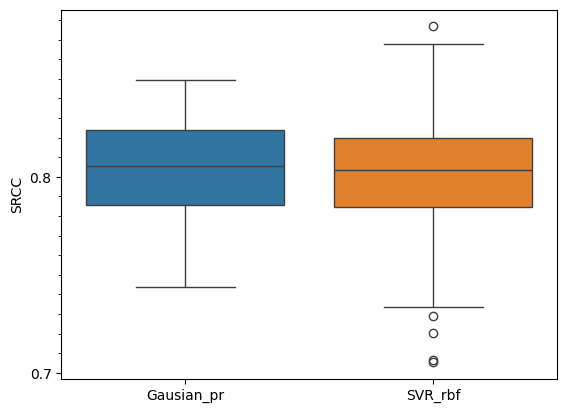

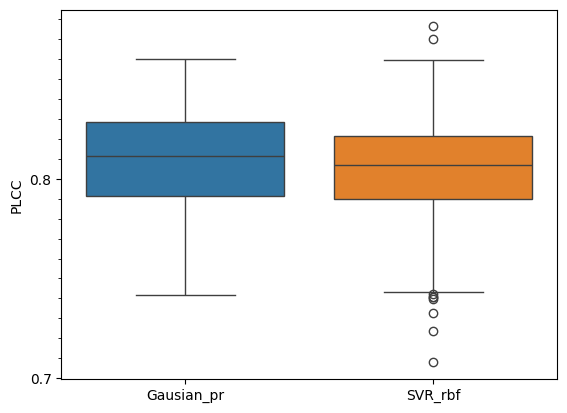

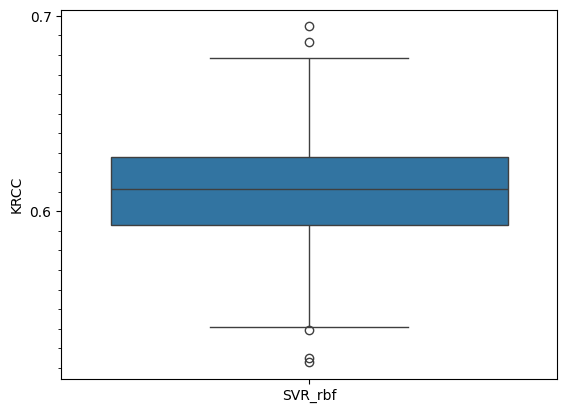

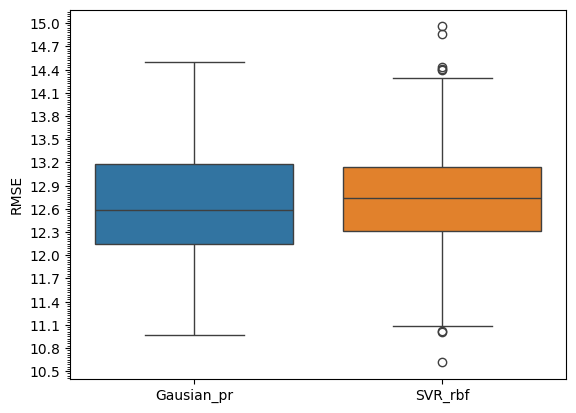

Gausian_pr    900
SVR_rbf         0
dtype: int64


In [25]:
import seaborn as sns 
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


def detailed_boxplot(data, ylabel, interval):
    sns.boxplot(data)
    plt.ylabel(ylabel)
    ax = plt.gca()
    ax.yaxis.set_major_locator(mticker.MultipleLocator(interval))  # Set major ticks at specific intervals
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(10))       # Add minor ticks
    plt.show()
# rmse_filtered = rmse[rmse['MLP'] < 2.4]
rmse_filtered = rmse

# Generate detailed boxplots
detailed_boxplot(srcc, 'SRCC', interval=.1)
detailed_boxplot(plcc, 'PLCC', interval=.1)
detailed_boxplot(krcc, 'KRCC', interval=.1)
detailed_boxplot(rmse_filtered, 'RMSE', interval=.3)

print(rmse.isna().sum())